## This is a sample Machine Learning project that exemplifies how to proceed Linear Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Networkx, Pingouin, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
from scipy.stats import boxcox
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from statstests.process import stepwise
import networkx as nx
import pingouin as pg
import seaborn as sns
import plotly.graph_objects as go
import os
import plotly.io as pio
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

  Using cached statstests-1.0.9-py3-none-any.whl.metadata (1.7 kB)
Using cached statstests-1.0.9-py3-none-any.whl (16 kB)


- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Travel Time = f(Distance). Simple Linear Regression.

This is the simplest use-case for Generalized Linear Models (GLMs) of type Simple Linear Regression (SLR). Here, we have a dataset that basically has the time as a function of the distance for a person to reach a certain place (e.g. a school or university). The only variable X (explicative variable) is the distance to travel, and the Y (dependent variable) is the time to reach the destination. We have thus the actual Y time (given at our dataset), as well as the estimated, predicted or expected Ŷ (Y hat) time (which composes the trend line). We show how to calculate the OLS (Ordinary Least Squares) linear model (function) of the trend line - finding its coefficients (linear and angular) and residuals (Y-Ŷ), as well as the R2 (coefficient of determination), that basically is the sq of the pearson correlation between the actual Y and X values. This R2 coefficient represents how well our model predicts Y based on X, i.e., what percent of Y variance is explained by X, considered the errors (between Y and Ŷ).

In [2]:
# reading and displaying our dataset
# time is in minutes, distance is in Kilometers
time_distance_df = pd.read_csv('time-distance.csv', delimiter=',')
time_distance_df

,time,distance
0,15,8
1,20,6
2,20,15
3,40,20
4,50,25
5,25,11
6,10,5
7,55,32
8,35,28
9,30,20


In [3]:
time_distance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   time      10 non-null     int64
 1   distance  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [4]:
time_distance_df.describe()

,time,distance
count,10.00000,10.000000
mean,30.00000,17.000000
std,14.90712,9.510228
min,10.00000,5.000000
25%,20.00000,8.750000
50%,27.50000,17.500000
75%,38.75000,23.750000
max,55.00000,32.000000


Simple Linear Regression formula. Yi observed values function contains the error (deviation) ui variable, while the Ŷi expected (fitted) values function does not contain the error variable - the rest of the function expression is the same. The line is actually the expected (fitted) values, while the Y observed values are the dispersed, scattered, cloud of actual values that deviate from that theoretical line. The closer the dispersed actual values are from the theoretical fitted-value line, the better the predictivity of that regression model (therefore, the higher the R2). The optimal regression model would be the one with R2 equal 1 and all actual observed values exactly at the line, that is, exactly equal to the expected, fitted, values. See below.

![./simple_linear_regression.png](simple_linear_regression.png)

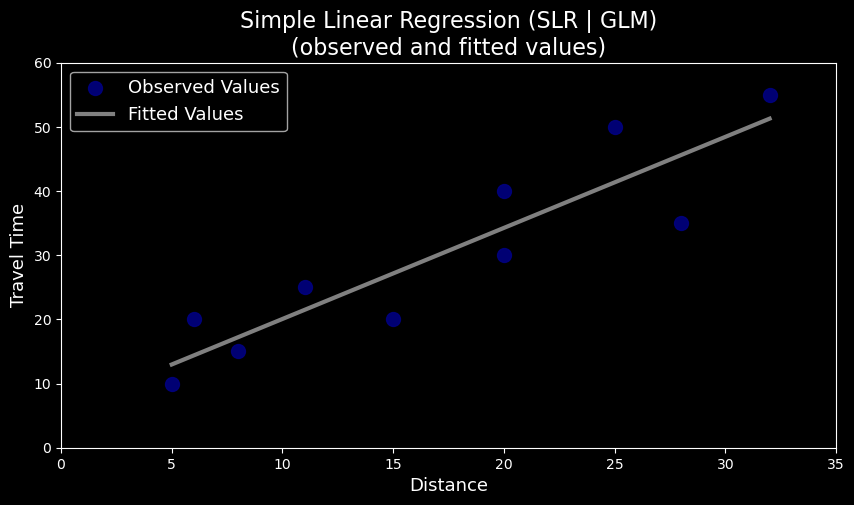

In [5]:
# Plotting scatter graph for SLR (GLM) of our dataset, with actual values (observed data) and fitted values (expected data)
plt.figure(figsize=(10,5))
sns.regplot(data=time_distance_df, x='distance', y='time', marker='o', ci=False,
            scatter_kws={"color":'navy', 'alpha':0.9, 's':100},
            line_kws={"color":'grey', 'linewidth': 3})
plt.title('Simple Linear Regression (SLR | GLM)\n(observed and fitted values)', fontsize=16)
plt.xlabel('Distance', fontsize=13)
plt.ylabel('Travel Time', fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 35)
plt.ylim(0, 60)
plt.legend(['Observed Values', 'Fitted Values'], fontsize=13, loc='upper left')
plt.show()

In [6]:
# Plotting INTERACTIVE scatter graph for SLR (GLM) of our dataset, with observed (actual) and fitted values
x = time_distance_df['distance']
y = time_distance_df['time']

slope, intercept = np.polyfit(x, y, 1)
y_trend = slope * x + intercept

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x,
    y=y,
    mode='markers',
    marker=dict(color='navy', size=20), name='Observed Values')
    )

fig.add_trace(go.Scatter(
    x=x,
    y=y_trend,
    mode='lines',
    line=dict(color='dimgray', width=5), name='Fitted Values')
    )

fig.update_traces(
    marker=dict(size=14)
)

fig.update_layout(
    width=850,
    height=500,
    xaxis_title='Distance',
    yaxis_title='Travel Time',
    title={
        'text': 'Simple Linear Regression (SLR | GLM)<br>'
                '<span style="font-size:16px; color:gray;">Observed vs Fitted Values</span>',
        'font': {'size': 20, 'color': 'black', 'family': 'Arial'},
        'x': 0.5,
        'y': 0.90,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    margin=dict(t=120),
    plot_bgcolor='snow',
    xaxis=dict(gridcolor='black'),
    yaxis=dict(gridcolor='black'),
    showlegend=True
)

fig.show()

![./ols.png](./ols.png)

In [7]:
# Estimating and displaying the OLS model
# Summation of residuals (Y-Ŷ) must be 0 ; Summation of squares of residuals must be minimal (Ordinary Least Squares - OLS)
# Yi = β0 + β1 * Xi + εi , being β0 the linear coefficient (Y axis intercept), β1 the angular coefficient or slope, εi the 
# residual or error (Y-Ŷ), and Xi and Yi the values of X axis and Y axis respectively, for each i observation. In this case, Yi 
# is the actual (observed) value of Y, as we're considering the ε . If not considering ε , we'd have Ŷ (Y hat). β0 can also be 
# called alfa, while ε can also be symbolized by ui .
ols_model = sm.OLS.from_formula('time ~ distance', time_distance_df).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   time   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     36.30
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000314
Time:                        14:12:03   Log-Likelihood:                -32.123
No. Observations:                  10   AIC:                             68.25
Df Residuals:                       8   BIC:                             68.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.8784      4.532      1.297      0.231      -4.573      16.330
distance       1.4189      0.235      6.025      0.000       0.876       1.962
==============================================================================
Omnibus:                        1.016   Durbin-Watson:                   2.099
Prob(Omnibus):                  0.602   Jarque-Bera (JB):                0.694
Skew:                          -0.262   Prob(JB):                        0.707
Kurtosis:                       1.820   Cond. No.                         41.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
# mounting the model (trend line) equation
params = ols_model.params
print(f'alfa (intercept) = {params["Intercept"]}\nbeta (distance slope) = {params["distance"]}')
terms = [f"{coef:.4f}*{name}" for name, coef in params.items() if name != "Intercept"]
equation = f"time = {params['Intercept']:.4f} + " + " + ".join(terms)
print(equation)

alfa (intercept) = 5.878378378378361
beta (distance slope) = 1.4189189189189193
time = 5.8784 + 1.4189*distance


In [9]:
# adding calculated Ŷi (fitted values) and residuals (ui), of each observation i, to the dataset
time_distance_df["yhat"] = ols_model.fittedvalues
time_distance_df["residual"] = ols_model.resid
time_distance_df

,time,distance,yhat,residual
0,15,8,17.229730,-2.229730
1,20,6,14.391892,5.608108
2,20,15,27.162162,-7.162162
3,40,20,34.256757,5.743243
4,50,25,41.351351,8.648649
5,25,11,21.486486,3.513514
6,10,5,12.972973,-2.972973
7,55,32,51.283784,3.716216
8,35,28,45.608108,-10.608108
9,30,20,34.256757,-4.256757


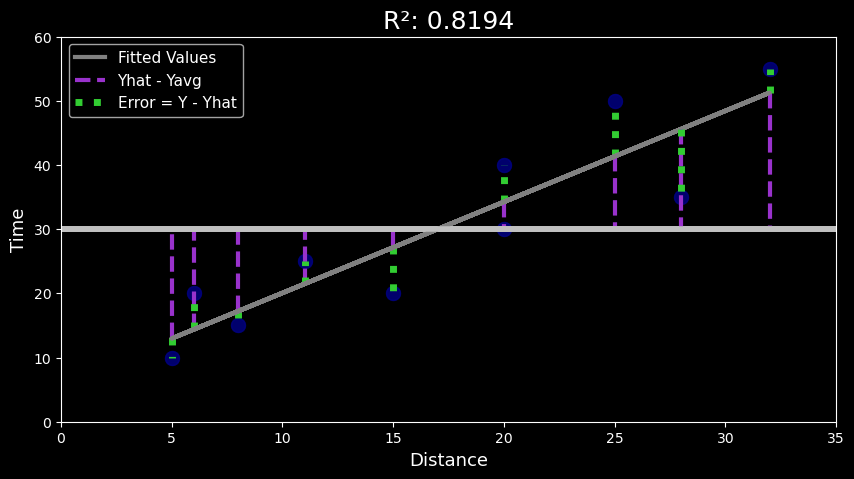

In [10]:
# Graphical view of R2 and error (residuals) concept
# Observe that residuals are the observed (actual) (Yi) values minus the expected (fitted) values (Ŷi) (in green), these are used
# to calculate the Residual Sum of Squares (SSR), at the R2 formula.
# Observe, also, the difference between the Ŷ (Yhat, expected, fitted, values) and the Yavg (in purple), which are used to 
# calculate the Explained Sum of Squares (ESS), at R2 formula.
# Observe, finally, that the difference between the Y (observed values) and the Yavg (green + purple), which are used to calculate 
# the Total Sum of Squares (TSS), at R2 formula.
# Yavg is the mean Y (observed) values, not the mean of the Ŷ (fitted) values.
plt.figure(figsize=(10,5))
y = time_distance_df['time']
yhat = time_distance_df['yhat']
x = time_distance_df['distance']
mean = np.full(x.shape[0] , y.mean(), dtype=int)
for i in range(len(x)-1):
    plt.plot(x, yhat, color='grey', linewidth=3)
    plt.plot([x[i], x[i]], [yhat[i], mean[i]], '--', color='darkorchid',
             linewidth=3)
    plt.plot([x[i], x[i]], [yhat[i], y[i]],':', color='limegreen', linewidth=5)
    plt.scatter(x, y, color='navy', s=100, alpha=0.2)
    plt.axhline(y = y.mean(), color = 'silver', linestyle = '-', linewidth=4)
    plt.title('R²: ' + str(round(ols_model.rsquared, 4)), fontsize=18)
    plt.xlabel('Distance', fontsize=13)
    plt.ylabel('Time', fontsize=13)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlim(0, 35)
    plt.ylim(0, 60)
    plt.legend(['Fitted Values', 'Yhat - Yavg', 'Error = Y - Yhat'],
               fontsize=11, loc='upper left')
plt.show()

R2 formula:

![r2.png](r2.png)

In [11]:
# calculating R2 manually - the result is the same as the one calculated by the statsmodels ols_model.summary() above
R2 = ((time_distance_df['yhat']-
       time_distance_df['time'].mean())**2).sum()/(((time_distance_df['yhat']-
                                        time_distance_df['time'].mean())**2).sum()+
                                        (time_distance_df['residual']**2).sum())

print(f"R2 = {R2}")

R2 = 0.8194256756756758


In [12]:
# another way of calculating R2 is by calculating the correlation of perason of Y and X. The R is the pearson correlation between 
# Y and X, and R2 is its square:
time_distance_df[["time","distance"]].corr()**2

,time,distance
time,1.000000,0.819426
distance,0.819426,1.000000


In [13]:
# a last way to obtain the R2 directly from the ols model is:
print(f"R2 = {ols_model.rsquared}")

R2 = 0.8194256756756757


In [14]:
# R2 (coefficient of determination) represents the percentage of Y values that is explained by the set of one or more X explicative 
# variables (in the case of SLR, only one X)... i.e., how much the explicative variable(s) contribute(s) to the value or variance 
# of the Y actual values of the model. Or in other terms, how good is our model in predicting Y values from X values. R2 varies 
# from 0 to 1, being 1 the perfect model, with 100% prediction capability, and 0 the worst model, with no prediction capability at 
# all.

# Only the fitted-value line parameters and the R2 (coefficient of determination) are not sufficient to define the ideal 
# fitted-value line, we gotta proceed hypothesis tests.

In [15]:
# If we set the Ŷ as dependent variable when defining a model, that is, if the Y (observed values) is exactly the Ŷ (expected,
# fitted, values), we'd have an R2 of 100%, 'cause the errors (residuals) would be 0, and thus the R2 formula would result in 1 -
# the Explained Sum of Squares (ESS) would be divided by itself, as the Residual Sum of Squares (SSR) would be zero.
# (see above).

perfect_model = sm.OLS.from_formula('yhat ~ distance', time_distance_df).fit()
perfect_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   yhat   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.598e+31
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          1.72e-122
Time:                        14:12:04   Log-Likelihood:                 309.16
No. Observations:                  10   AIC:                            -614.3
Df Residuals:                       8   BIC:                            -613.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.8784   6.83e-15   8.61e+14      0.000       5.878       5.878
distance       1.4189   3.55e-16      4e+15      0.000       1.419       1.419
==============================================================================
Omnibus:                       13.263   Durbin-Watson:                   0.046
Prob(Omnibus):                  0.001   Jarque-Bera (JB):                1.667
Skew:                           0.000   Prob(JB):                        0.435
Kurtosis:                       1.000   Cond. No.                         41.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
print(f"R2 = {perfect_model.rsquared}")

R2 = 1.0


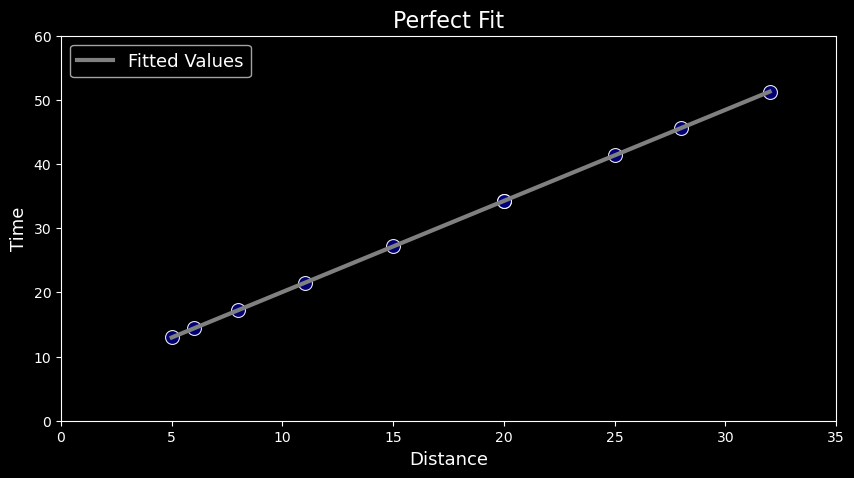

In [17]:
# Plotting scatter graph for SLR (GLM) of the perfect model above
plt.figure(figsize=(10,5))
sns.scatterplot(data=time_distance_df, x='distance', y='yhat',
                color='navy', alpha=0.9, s=100)
sns.regplot(data=time_distance_df, x='distance', y='yhat', ci=False, scatter=False,
            label='Fitted Values',
            line_kws={"color":'grey', 'linewidth': 3})
plt.title('Perfect Fit', fontsize=16)
plt.xlabel('Distance', fontsize=13)
plt.ylabel('Time', fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 35)
plt.ylim(0, 60)
plt.legend(loc='upper left', fontsize=13)
plt.show()

In [18]:
# below we discuss how to calculate the CI, for alfa and beta, when considered the sample x population prediction values, and how 
# this calculation affects the significance of our regression model in terms of prediction acertainty, including the relationship
# between the CI and the R2

CI / R2 formula and relationship:

![ci-r2-relationship.png](ci-r2-relationship.png)

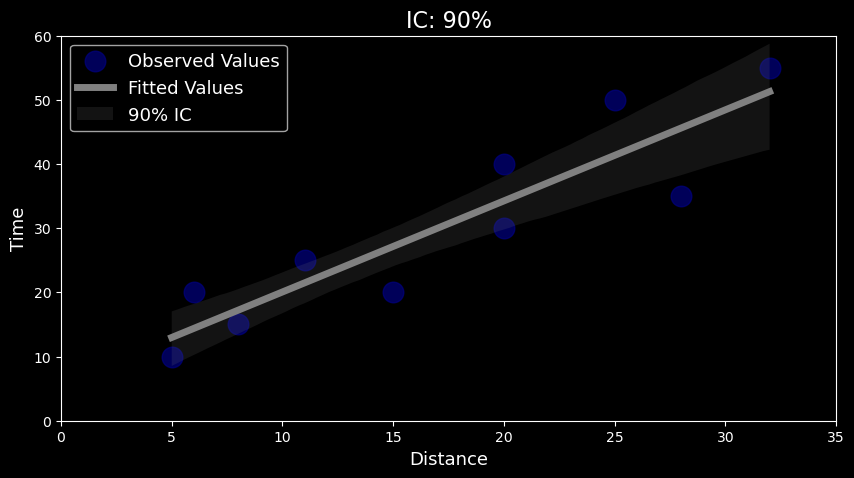

                       Lower bound  Upper bound
Intercept (alfa)         -2.549702    14.306459
distance (beta slope)     0.981001     1.856837


In [19]:
# Re-plotting the original SLR graph up above, now with the CI of 90%.
# The observed values used here, based on which we estimated the trend line for the fitted values (Ŷ hat), are a sample of a 
# whole population. Confidence level (and respective Confidence intervals for parameters), in a linear regression model, refers 
# mainly to the beta parameter (slope) range, graphically the shaded area, within which the population true beta probably lies. 
# This is not directly a range of possible X and Y values, but of beta (slope) values of the regression line itself (when applied
# as a predictor of real population observations). The more certainty we want on the beta true value, the wider the shaded area 
# must be. Mathematically, this is due to the fact that the higher the confidence level, the larger the t critical value for the 
# significance level (1-confidence level), thus the wider the CI range also will be - i.e., the range for the actual population 
# beta value, not for the X or Y values, directly. The main thing is that, for the hypothesis test, regarding the true value of 
# beta (H0 is beta equal to 0), for the test to reject the null hypothesis and we have a statistically significant beta, different 
# from 0, the CI range or interval MUST NOT contain 0, that is, the possible beta values MUST NOT include beta=0, because, if this
# case happens, the slope would be 0 and there would be no relationship at all between X and Y values - the fitted values' line 
# would be flat and there would be no relation between Distance and Time variables, and, therefore, no prediction. So, the 
# regression analysis is only significant if the CI range of population beta value DOES NOT include 0 as a possible value for the 
# beta (slope). The CI range for beta must be some interval above (positive relationship) or below zero (negative relationship), 
# but must not include 0. 

# Observe, at the graphs below, how increasing CI of beta also increases the range of the CI, until it starts including zero, and 
# therefore turning our regression model statistically not significant for that CI (with a possible beta=0) - even though the model 
# fitted line and its parameters are the same, if considered only the sample fitted values. The regression line does not change, 
# what changes is its CI. A prediction model is useless if, when applied to a general population, in future predictions, it has 
# no confidence that the predictivity will even exist (i.e., Y will be explainable by X), let alone with the same accuracy obtained 
# at the training phase (sample data alone). Also, the higher the R2, the shorter the standard error (SE), and the narrower tends 
# to be that CI range (though it also depends on X variability and sample size - see formulas above).

# The CI itself does NOT affect the F and t tests calculated and shown at the model summary above, regarding the significance of 
# the predicting model as a whole and of its explicative variable(s), or the calculated parameters (alfa and beta), but it does 
# affect the applicability of the model when predicting values to a real population - which is the actual goal of the model. For
# the real population, the regression line probably will differ a bit, within the CI range, but it should keep the significance
# of the beta (and the model as a whole) as long as the CI does not include the possibility of beta being 0.

# In conclusion, for our SLR model to be significant and useful, we must have a sufficiently high R2, combined with low p-values, 
# for both the F test (of the model) and t test (of the explicative variable individually). At SLR, these two tests have the same 
# result, as we have only one explicative variable (and beta), responsible for the total significance of the model predictiveness. 
# But we must also have a CI range of beta that does not include zero... this way, our dependent variable will be explainable by 
# the explicative variable, at that CI, when considered future population inputs, with the calculated F significance (the 
# significance of the only beta is the significance of the model). Finally, as best as our model might be, its predictiviness only 
# applies to the interpolation range (min-max X values) considered, not to extrapolations.

plt.figure(figsize=(10,5))
sns.regplot(data=time_distance_df, x='distance', y='time', marker='o', ci=90,
            scatter_kws={"color":'navy', 'alpha':0.7, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('IC: 90%', fontsize=16)
plt.xlabel('Distance', fontsize=13)
plt.ylabel('Time', fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 35)
plt.ylim(0, 60)
plt.legend(['Observed Values', 'Fitted Values', '90% IC'],
           fontsize=13, loc='upper left')
plt.show()
print(ols_model.conf_int(alpha=0.1).rename(index={"Intercept": "Intercept (alfa)", "distance": "distance (beta slope)"}, columns={0: 'Lower bound', 1: 'Upper bound'}))

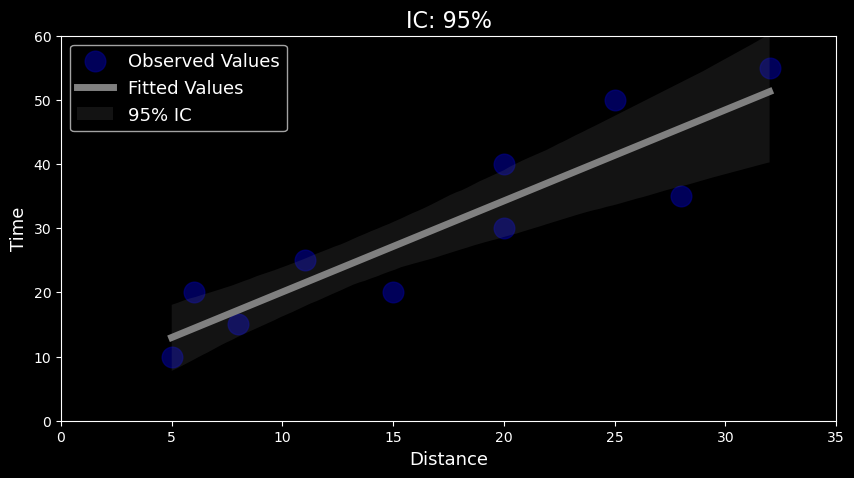

                       Lower bound  Upper bound
Intercept (alfa)         -4.573188    16.329944
distance (beta slope)     0.875861     1.961977


In [20]:
# Re-plotting the original SLR graph up above, now with the CI of 95%.

plt.figure(figsize=(10,5))
sns.regplot(data=time_distance_df, x='distance', y='time', marker='o', ci=95,
            scatter_kws={"color":'navy', 'alpha':0.7, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('IC: 95%', fontsize=16)
plt.xlabel('Distance', fontsize=13)
plt.ylabel('Time', fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 35)
plt.ylim(0, 60)
plt.legend(['Observed Values', 'Fitted Values', '95% IC'],
           fontsize=13, loc='upper left')
plt.show()
print(ols_model.conf_int(alpha=0.05).rename(index={"Intercept": "Intercept (alfa)", "distance": "distance (beta slope)"}, columns={0: 'Lower bound', 1: 'Upper bound'}))

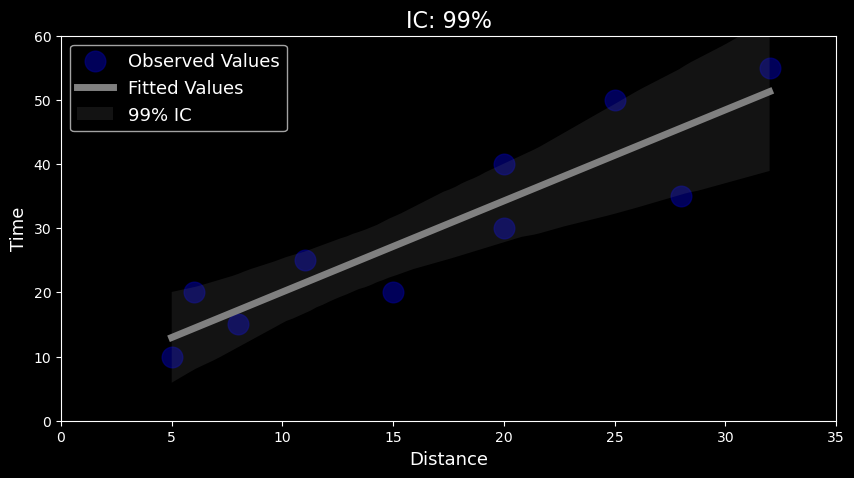

                       Lower bound  Upper bound
Intercept (alfa)         -9.329336    21.086093
distance (beta slope)     0.628735     2.209103


In [21]:
# Re-plotting the original SLR graph up above, now with the CI of 99%.

plt.figure(figsize=(10,5))
sns.regplot(data=time_distance_df, x='distance', y='time', marker='o', ci=99,
            scatter_kws={"color":'navy', 'alpha':0.7, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('IC: 99%', fontsize=16)
plt.xlabel('Distance', fontsize=13)
plt.ylabel('Time', fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 35)
plt.ylim(0, 60)
plt.legend(['Observed Values', 'Fitted Values', '99% IC'],
           fontsize=13, loc='upper left')
plt.show()
print(ols_model.conf_int(alpha=0.01).rename(index={"Intercept": "Intercept (alfa)", "distance": "distance (beta slope)"}, columns={0: 'Lower bound', 1: 'Upper bound'}))

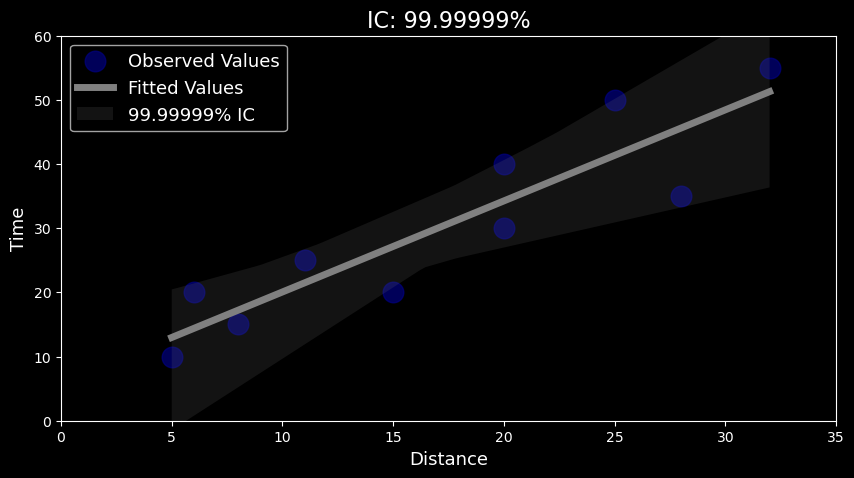

                       Lower bound  Upper bound
Intercept (alfa)        -74.960201    86.716957
distance (beta slope)    -2.781409     5.619247


In [22]:
# Re-plotting the original SLR graph up above, now with the CI of 99.99999%.

plt.figure(figsize=(10,5))
sns.regplot(data=time_distance_df, x='distance', y='time', marker='o', ci=99.99999,
            scatter_kws={"color":'navy', 'alpha':0.7, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('IC: 99.99999%', fontsize=16)
plt.xlabel('Distance', fontsize=13)
plt.ylabel('Time', fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 35)
plt.ylim(0, 60)
plt.legend(['Observed Values', 'Fitted Values', '99.99999% IC'],
           fontsize=13, loc='upper left')
plt.show()
print(ols_model.conf_int(alpha=0.0000001).rename(index={"Intercept": "Intercept (alfa)", "distance": "distance (beta slope)"}, columns={0: 'Lower bound', 1: 'Upper bound'}))

In [23]:
# observe that, for a confidence interval of 99.99999% (beta range = -2.781409, 5.619247), the beta (for the distance variable) has 
# no confidence anymore, therefore our model turns out to be unusable, as it starts admitting the possibility that beta is 0, and,
# if that's the case, Time would not be explainable by Distance any longer, and any predictions on population inputs would be 
# untrustful. We should therefore reduce the CI or increase the number of observations, so that, maybe, the model would have
# confidence again (with CI not including 0 anymore).

In [24]:
# Regardless the CIs, let's make some predictions based on the regression model above (sample-based):
# Time predicted (in minutes) for a distance of 25Km ?
print(f'A distance of 25Km would take around {round(ols_model.params["Intercept"]+ols_model.params["distance"]*25,2)} minutes.')

A distance of 25Km would take around 41.35 minutes.


In [25]:
# Or:

ols_model.predict(pd.DataFrame({'distance':[25]}))

0    41.351351
dtype: float64

In [26]:
# A final observation, regarding the model summary above, is that, if the explicative variable beta is not significant (p-value
# >= 0.05, CI 95%), it should be removed from the model - for SLR models, this would invalidate the model completely at that CI, 
# as there's only one variable and beta. But, if the alfa (intercept) alone is not significant, with at least one beta being 
# significant (in SLR we only have one), the model is still valid, and the not significant alfa won't affect the model 
# predictiveness. Insignificant alfas might be a matter of small sample sizes. Either way, we MUST ALWAYS KEEP the alfa at the 
# model regression expression, either significant or not. Turning alfa artificially zero, and excluding it from the model, is 
# completely wrong and introduces a great bias to our model... differently from excluding betas, when we have multiple betas to
# keep or eliminate - see Multiple Regression Model (MRM) examples at this same project directory.